# Sprint 6 - Support Vector Machine (SVM)

A partir del conjunto de datos `ASI_casoPractico.csv`:

1. A partir de los conjuntos de **entrenamiento** y **test** creados en el sprint 2, ajustar un modelo con el algoritmo **SVM** dejando los valores por defecto.
2. Obtener la curva ROC y el AUC para los conjuntos de entrenamiento y test.
3. Comparar en la misma gráfica la curva ROC y el AUC para el conjunto de test clasificado con **Naive Bayes** y con **SVM**.

**Objetivo:** aprender a ajustar el algoritmo de Support Vector Machine y validar su precisión a partir de la curva ROC y el área bajo la curva.

In [2]:
# IMPORTACION DE LIBRERIAS
import numpy as np
import pandas as pd

# LIBRERIAS PARA HACER GRAFICOS
import seaborn as sns
import matplotlib.pyplot as plt

# Configuracion de warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# CARGA DEL FICHERO DE DATOS
# En Colab, descomenta estas dos lineas para subir el CSV desde tu equipo:
# from google.colab import files
# files.upload()

file = 'ASI_casoPractico.csv'
data = pd.read_csv(file, sep=';', encoding='utf-8-sig')
data.head()

,ID,b,e,LBE,AC,FM,UC,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,1,240,357,120,0,0,0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,1
1,2,5,632,132,4,0,4,17,2.1,0,...,68,198,6,1,141,136,140,12,0,0
2,3,177,779,133,2,0,5,16,2.1,0,...,68,198,5,1,141,135,138,13,0,0
3,4,411,1192,134,2,0,6,16,2.4,0,...,53,170,11,0,137,134,137,13,1,0
4,5,533,1147,132,4,0,5,16,2.4,0,...,53,170,9,0,137,136,138,11,1,0


In [4]:
# INFORMACION DEL CONJUNTO DE DATOS
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        2126 non-null   int64  
 1   b         2126 non-null   int64  
 2   e         2126 non-null   int64  
 3   LBE       2126 non-null   int64  
 4   AC        2126 non-null   int64  
 5   FM        2126 non-null   int64  
 6   UC        2126 non-null   int64  
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  DL        2126 non-null   int64  
 12  DS        2126 non-null   int64  
 13  DP        2126 non-null   int64  
 14  DR        2126 non-null   int64  
 15  Width     2126 non-null   int64  
 16  Min       2126 non-null   int64  
 17  Max       2126 non-null   int64  
 18  Nmax      2126 non-null   int64  
 19  Nzeros    2126 non-null   int64  
 20  Mode      2126 non-null   int64  
 21  Me

In [5]:
# ELIMINAR COLUMNAS NO NECESARIAS (identificadores / sin informacion)
data = data.drop(["ID", "b", "e", "DR"], axis=1)
data.head()

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Target
0,120,0,0,0,73,0.5,43,2.4,0,0,...,62,126,2,0,120,137,121,73,1,1
1,132,4,0,4,17,2.1,0,10.4,2,0,...,68,198,6,1,141,136,140,12,0,0
2,133,2,0,5,16,2.1,0,13.4,2,0,...,68,198,5,1,141,135,138,13,0,0
3,134,2,0,6,16,2.4,0,23.0,2,0,...,53,170,11,0,137,134,137,13,1,0
4,132,4,0,5,16,2.4,0,19.9,0,0,...,53,170,9,0,137,136,138,11,1,0


## 1. Conjuntos de entrenamiento (60%) y test (40%) creados en el sprint 2

Se reproduce exactamente el mismo muestreo del sprint 2 (y sprint 5): 60% entrenamiento y
40% test con `random_state=0`, de modo que los conjuntos son idénticos y la comparación
entre Naive Bayes y SVM se realiza sobre las mismas observaciones.

In [6]:
# MUESTREO: ENTRENAMIENTO (60%) Y TEST (40%)  --> mismo split que el sprint 2
from sklearn.model_selection import train_test_split

X = data.loc[:, data.columns != "Target"]
y = data.loc[:, data.columns == "Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.60, random_state=0
)

print(f"Entrenamiento: {X_train.shape[0]} observaciones ({X_train.shape[0] / len(X):.0%})")
print(f"Test:          {X_test.shape[0]} observaciones ({X_test.shape[0] / len(X):.0%})")

Entrenamiento: 1275 observaciones (60%)
Test:          851 observaciones (40%)


## 2. Ajuste del modelo SVM con los valores por defecto

Se ajusta `svm.SVC()` **dejando los valores por defecto** (kernel `rbf`, `C=1.0`,
`gamma='scale'`). El único parámetro que se modifica es `probability=True`, imprescindible
para poder estimar las probabilidades (`predict_proba`) que necesita la curva ROC.

In [7]:
# MODELIZACION - SVM con valores por defecto
from sklearn import svm

svmModel = svm.SVC(probability=True)   # valores por defecto: kernel='rbf', C=1.0, gamma='scale'
modelSVM = svmModel.fit(X_train, y_train.values.ravel())

y_pred_train_svm = modelSVM.predict_proba(X_train)
y_pred_test_svm = modelSVM.predict_proba(X_test)

## 3. Curva ROC y área bajo la curva (AUC) para SVM

In [8]:
# VALIDACION SVM
from sklearn.metrics import roc_curve, auc

# CURVA ROC Y AUC PARA TRAINING
fpr_train_svm, tpr_train_svm, _ = roc_curve(y_train, y_pred_train_svm[:, 1])
roc_auc_train_svm = auc(fpr_train_svm, tpr_train_svm)

# CURVA ROC Y AUC PARA TEST
fpr_test_svm, tpr_test_svm, _ = roc_curve(y_test, y_pred_test_svm[:, 1])
roc_auc_test_svm = auc(fpr_test_svm, tpr_test_svm)

print(f"AUC entrenamiento (SVM): {roc_auc_train_svm:.4f}")
print(f"AUC test          (SVM): {roc_auc_test_svm:.4f}")

AUC entrenamiento (SVM): 0.9381
AUC test          (SVM): 0.9197


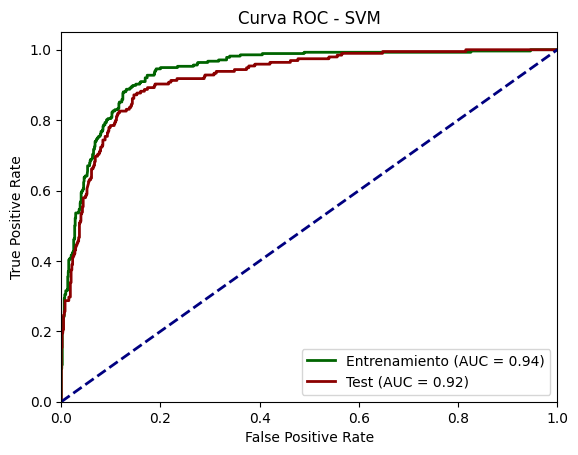

In [9]:
# GRAFICA DE LA CURVA ROC - SVM (entrenamiento vs test)
plt.figure()
lw = 2

plt.plot(fpr_train_svm, tpr_train_svm, color="darkgreen", lw=lw,
         label="Entrenamiento (AUC = %0.2f)" % roc_auc_train_svm)
plt.plot(fpr_test_svm, tpr_test_svm, color="darkred", lw=lw,
         label="Test (AUC = %0.2f)" % roc_auc_test_svm)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend(loc="lower right")
plt.show()

## 4. Comparación en test: Naive Bayes vs SVM

Se ajusta también el modelo **Naive Bayes** (sprint 5) sobre el mismo conjunto de
entrenamiento y se comparan ambas curvas ROC y sus AUC sobre el conjunto de **test**.

In [10]:
# AJUSTE NAIVE BAYES (mismo conjunto de entrenamiento que el sprint 5)
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
modelNB = gnb.fit(X_train, y_train.values.ravel())

y_pred_test_nb = modelNB.predict_proba(X_test)

# CURVA ROC Y AUC EN TEST - NAIVE BAYES
fpr_test_nb, tpr_test_nb, _ = roc_curve(y_test, y_pred_test_nb[:, 1])
roc_auc_test_nb = auc(fpr_test_nb, tpr_test_nb)

print(f"AUC test (Naive Bayes): {roc_auc_test_nb:.4f}")
print(f"AUC test (SVM):         {roc_auc_test_svm:.4f}")

AUC test (Naive Bayes): 0.9349
AUC test (SVM):         0.9197


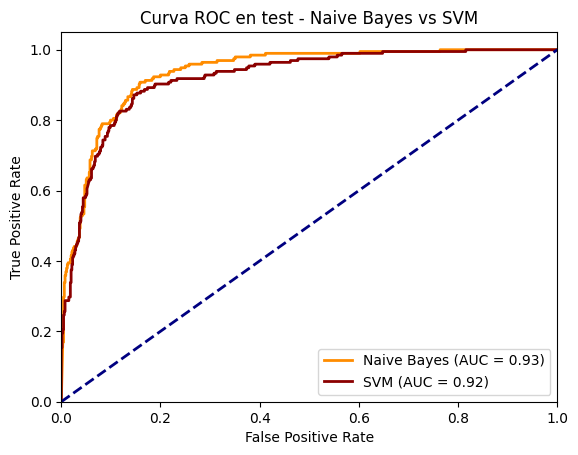

In [11]:
# GRAFICA COMPARATIVA DE LA CURVA ROC EN TEST: NAIVE BAYES vs SVM
plt.figure()
lw = 2

plt.plot(fpr_test_nb, tpr_test_nb, color="darkorange", lw=lw,
         label="Naive Bayes (AUC = %0.2f)" % roc_auc_test_nb)
plt.plot(fpr_test_svm, tpr_test_svm, color="darkred", lw=lw,
         label="SVM (AUC = %0.2f)" % roc_auc_test_svm)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC en test - Naive Bayes vs SVM")
plt.legend(loc="lower right")
plt.show()

## Conclusiones

- El modelo **SVM** se ajustó dejando los **valores por defecto** (kernel `rbf`, `C=1.0`,
  `gamma='scale'`), añadiendo únicamente `probability=True` para poder obtener las
  probabilidades necesarias para la curva ROC.
- La comparación del **AUC de entrenamiento y test** en SVM permite valorar la capacidad de
  generalización del modelo: una diferencia pequeña indica que el modelo no sobreajusta.
- Al comparar sobre el conjunto de **test**, el modelo con **mayor AUC** es el que ofrece mejor
  capacidad de discriminación entre clases. La gráfica comparativa muestra de forma directa
  qué algoritmo (Naive Bayes o SVM) clasifica mejor con los datos disponibles.